# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

**Diferencias entre LabelEncoder y OneHotEncoder:**

| Aspecto | LabelEncoder | OneHotEncoder |
|---------|--------------|---------------|
| Resultado | Una sola columna con enteros 0..N-1 | N columnas binarias (una por categoría) |
| Implica orden | Sí (los enteros pueden interpretarse como un ranking) | No (las categorías son independientes) |
| Uso recomendado | Variables **ordinales** o la variable objetivo de clasificación | Variables **nominales** (sin orden natural) |
| Dimensionalidad | No aumenta | Aumenta (una columna por categoría) |
| Riesgo principal | Inducir un orden falso que confunde al modelo | Alta dimensionalidad si hay muchas categorías |

En resumen: `LabelEncoder` asigna un número entero a cada categoría, mientras que `OneHotEncoder` crea una columna binaria por cada categoría posible, evitando introducir un orden artificial.

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

Mapeo aprendido por LabelEncoder: {'female': np.int64(0), 'male': np.int64(1)}


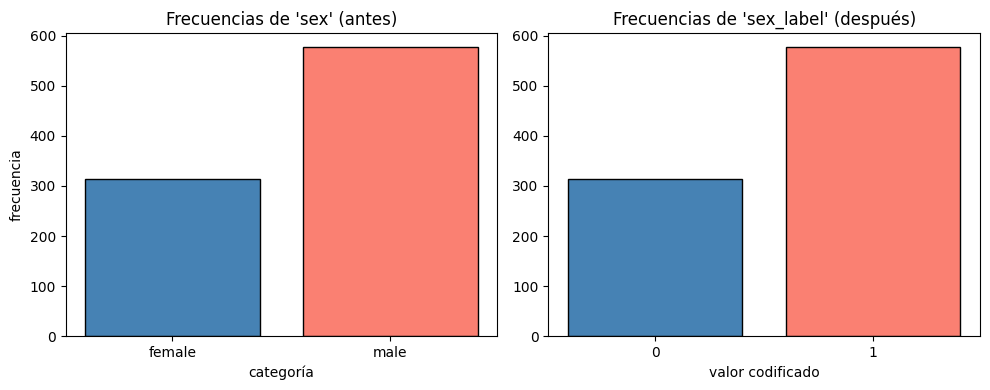

In [8]:
import matplotlib.pyplot as plt

# Frecuencias antes y después de LabelEncoder en 'sex'
freq_antes = data['sex'].value_counts().sort_index()
freq_despues = data['sex_label'].value_counts().sort_index()

# Mapa de etiquetas para entender qué entero representa cada categoría
mapa = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapeo aprendido por LabelEncoder:", mapa)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(freq_antes.index.astype(str), freq_antes.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title("Frecuencias de 'sex' (antes)")
axes[0].set_xlabel('categoría')
axes[0].set_ylabel('frecuencia')

axes[1].bar(freq_despues.index.astype(str), freq_despues.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title("Frecuencias de 'sex_label' (después)")
axes[1].set_xlabel('valor codificado')

plt.tight_layout()
plt.show()

# Las frecuencias son idénticas; LabelEncoder solo renombra las categorías,
# no cambia el conteo de cada una.

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [9]:
# OneHotEncoder para la columna 'class'
class_onehot = pd.get_dummies(data['class'], prefix='class')
data = pd.concat([data, class_onehot], axis=1)

print("Columnas creadas a partir de 'class':")
print(class_onehot.columns.tolist())
print("\nPrimeras filas con la codificación one-hot de 'class':")
print(data[['class'] + class_onehot.columns.tolist()].head(10))

# Ventajas frente a LabelEncoder:
# 1. No introduce un orden artificial entre 'First', 'Second' y 'Third' (aunque
#    aquí sí existe un orden, en general OneHot evita inducir relaciones falsas).
# 2. Cada categoría queda representada en su propia dimensión, lo que permite a
#    modelos lineales asignar pesos independientes a cada clase.
# 3. Es la representación adecuada para variables nominales en modelos como
#    regresión lineal/logística o redes neuronales.
# 4. Evita que el modelo interprete que 'Third' (2) es "el doble" de 'Second' (1).

Columnas creadas a partir de 'class':
['class_First', 'class_Second', 'class_Third']

Primeras filas con la codificación one-hot de 'class':
    class  class_First  class_Second  class_Third
0   Third        False         False         True
1   First         True         False        False
2   Third        False         False         True
3   First         True         False        False
4   Third        False         False         True
5   Third        False         False         True
6   First         True         False        False
7   Third        False         False         True
8   Third        False         False         True
9  Second        False          True        False


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

**Respuesta:**

La elección depende del **tipo de variable categórica** y del **modelo** que se use:

1. **Variables nominales (sin orden natural)** — p. ej. `sex`, `embarked`, `embark_town`:
   - **OneHotEncoder** (o `pd.get_dummies`) es la mejor opción.
   - Evita inducir un orden falso entre categorías y permite a modelos lineales
     o basados en distancia (regresión logística, SVM, KNN, redes neuronales)
     tratar cada categoría de manera independiente.

2. **Variables ordinales (con orden natural)** — p. ej. `class` (First < Second < Third):
   - Puede usarse `OrdinalEncoder` (o `LabelEncoder` con cuidado) respetando
     el orden, ya que el orden sí aporta información útil al modelo.

3. **Modelos basados en árboles** (Random Forest, XGBoost, LightGBM):
   - Toleran bien la codificación entera (`LabelEncoder`) porque hacen
     particiones por umbrales y no interpretan los enteros como magnitudes.
   - Aun así, OneHot funciona, pero puede aumentar mucho la dimensionalidad.

4. **Cardinalidad alta** (muchas categorías distintas):
   - One-hot puede explotar el número de columnas. En esos casos se prefieren
     técnicas como **Target Encoding**, **Frequency Encoding** o **Embeddings**.

**Regla práctica:** para este dataset y un modelo lineal o de distancia, usaría
`OneHotEncoder` para variables nominales (`sex`, `embarked`) y mantendría
`class` como ordinal codificada con orden explícito (`Third`=0, `Second`=1, `First`=2).